In [1]:
import os
import glob
import json
import torch
import pandas as pd
import numpy as np

from PIL import Image
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

PyTorch: 2.7.1+cu118
CUDA available: True
Device: cuda


In [6]:
# ============================================================
# CELL 2 — PATHS AND CONFIGURATION
# ============================================================

import os
import torch

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

TEST_DIR = r"C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images"

MODEL_PATH = r"C:\Users\srima\Desktop\HyperVerge\hv_ai_outputs\best_phase1_model.pt"

OUTPUT_DIR = r"C:\Users\srima\Desktop\HyperVerge\hv_ai_outputs\test_Csv"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# DEVICE
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# ------------------------------------------------------------
# CHECK PATHS
# ------------------------------------------------------------

print("=" * 60)
print("PATH CHECK")
print("=" * 60)

print("\nTest directory:")
print(TEST_DIR)

print("Exists:", os.path.exists(TEST_DIR))
print("Is directory:", os.path.isdir(TEST_DIR))

print("\nModel:")
print(MODEL_PATH)

print("Exists:", os.path.exists(MODEL_PATH))
print("Is file:", os.path.isfile(MODEL_PATH))

print("\nOutput directory:")
print(OUTPUT_DIR)

print("Exists:", os.path.exists(OUTPUT_DIR))

print("\nDevice:", DEVICE)

# ------------------------------------------------------------
# FIND TEST IMAGES
# ------------------------------------------------------------

if not os.path.isdir(TEST_DIR):
    raise FileNotFoundError(
        f"\nTest directory not found:\n{TEST_DIR}"
    )

test_images = [
    f for f in os.listdir(TEST_DIR)
    if f.lower().endswith(
        (".jpg", ".jpeg", ".png", ".webp")
    )
]

print("\nNumber of test images:", len(test_images))

print("\nFirst 10 test images:")

for img in test_images[:10]:
    print("  ", img)

# ------------------------------------------------------------
# VERIFY SAMPLE IMAGE
# ------------------------------------------------------------

sample_image = os.path.join(
    TEST_DIR,
    "0_2.jpeg"
)

print("\nSample image:")
print(sample_image)

if os.path.isfile(sample_image):
    print("✓ Sample image found")
else:
    print("⚠ Sample image not found")

# ------------------------------------------------------------
# VERIFY MODEL
# ------------------------------------------------------------

if not os.path.isfile(MODEL_PATH):
    raise FileNotFoundError(
        f"\nPhase 1 model not found:\n{MODEL_PATH}"
    )

print("\n✓ Phase 1 model found.")

print(
    "Model size:",
    round(
        os.path.getsize(MODEL_PATH) / (1024 * 1024),
        2
    ),
    "MB"
)

print("\n" + "=" * 60)
print("✓ PATHS VERIFIED")
print("=" * 60)

PATH CHECK

Test directory:
C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images
Exists: True
Is directory: True

Model:
C:\Users\srima\Desktop\HyperVerge\hv_ai_outputs\best_phase1_model.pt
Exists: True
Is file: True

Output directory:
C:\Users\srima\Desktop\HyperVerge\hv_ai_outputs\test_Csv
Exists: True

Device: cuda

Number of test images: 10477

First 10 test images:
   0_1034.jpeg
   0_1045.jpeg
   0_1085.jpeg
   0_110.jpeg
   0_1104.jpeg
   0_1115.jpeg
   0_1124.jpeg
   0_1184.jpeg
   0_1216.jpeg
   0_1218.jpeg

Sample image:
C:\Users\srima\Desktop\HyperVerge\HV-AI-2025-Test\HV-AI-2025-Test\test_images\0_2.jpeg
✓ Sample image found

✓ Phase 1 model found.
Model size: 128.09 MB

✓ PATHS VERIFIED


In [7]:
# ============================================================
# CELL 3 — IMPORTS
# ============================================================

import os
import glob
import torch
import torch.nn as nn
import pandas as pd

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

PyTorch: 2.7.1+cu118
Device: cuda


In [8]:
# ============================================================
# CELL 4 — CLASS MAPPING
# ============================================================

CLASS_NAMES = [
    "cane",
    "cavallo",
    "elefante",
    "farfalla",
    "gallina",
    "gatto",
    "mucca",
    "pecora",
    "ragno",
    "scoiattolo"
]

NUM_CLASSES = len(CLASS_NAMES)

print("Number of classes:", NUM_CLASSES)

for idx, name in enumerate(CLASS_NAMES):
    print(f"{idx}: {name}")

Number of classes: 10
0: cane
1: cavallo
2: elefante
3: farfalla
4: gallina
5: gatto
6: mucca
7: pecora
8: ragno
9: scoiattolo


In [9]:
# ============================================================
# CELL 5 — FIND TEST IMAGES
# ============================================================

extensions = [
    "*.jpg",
    "*.jpeg",
    "*.JPG",
    "*.JPEG",
    "*.png",
    "*.PNG",
    "*.webp",
    "*.WEBP"
]

test_image_paths = []

for extension in extensions:
    test_image_paths.extend(
        glob.glob(
            os.path.join(TEST_DIR, extension)
        )
    )

test_image_paths = sorted(set(test_image_paths))

print("Total test images:", len(test_image_paths))

if len(test_image_paths) == 0:
    raise RuntimeError(
        f"No images found in:\n{TEST_DIR}"
    )

print("\nFirst 10 images:")

for path in test_image_paths[:10]:
    print(os.path.basename(path))

Total test images: 10477

First 10 images:
0_1034.jpeg
0_1045.jpeg
0_1085.jpeg
0_110.jpeg
0_1104.jpeg
0_1115.jpeg
0_1124.jpeg
0_1184.jpeg
0_1216.jpeg
0_1218.jpeg


In [10]:
# ============================================================
# CELL 6 — TEST TRANSFORM
# ============================================================

IMG_SIZE = 224

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✓ Test transform ready")

✓ Test transform ready


In [11]:
# ============================================================
# CELL 7 — TEST DATASET
# ============================================================

class TestDataset(Dataset):

    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):

        image_path = self.image_paths[index]

        try:
            image = Image.open(
                image_path
            ).convert("RGB")

        except Exception as e:
            raise RuntimeError(
                f"Could not read image:\n{image_path}\n{e}"
            )

        if self.transform:
            image = self.transform(image)

        return image, image_path


test_dataset = TestDataset(
    test_image_paths,
    transform=test_transform
)

print("✓ Test dataset created")
print("Images:", len(test_dataset))

✓ Test dataset created
Images: 10477


In [12]:
# ============================================================
# CELL 8 — TEST DATALOADER
# ============================================================

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Batch size:", 32)
print("Number of batches:", len(test_loader))

Batch size: 32
Number of batches: 328


In [13]:
# ============================================================
# CELL 9 — CREATE RESNET-18
# ============================================================

model = models.resnet18(weights=None)

model.fc = nn.Linear(
    model.fc.in_features,
    NUM_CLASSES
)

model = model.to(DEVICE)

print("✓ ResNet-18 created")
print("Final layer:", model.fc)

✓ ResNet-18 created
Final layer: Linear(in_features=512, out_features=10, bias=True)


In [14]:
# ============================================================
# CELL 10 — LOAD PHASE 1 MODEL
# ============================================================

print("Loading:")
print(MODEL_PATH)

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE
)

print("\nCheckpoint loaded.")
print("Checkpoint type:", type(checkpoint))

Loading:
C:\Users\srima\Desktop\HyperVerge\hv_ai_outputs\best_phase1_model.pt

Checkpoint loaded.
Checkpoint type: <class 'dict'>


In [15]:
# ============================================================
# CELL 11 — INSPECT CHECKPOINT
# ============================================================

if isinstance(checkpoint, dict):

    print("Checkpoint keys:")

    for key in checkpoint.keys():
        print(" -", key)

else:

    print("Checkpoint is directly a state_dict.")

Checkpoint keys:
 - model_state_dict
 - class_names
 - label_to_idx
 - img_size
 - imagenet_mean
 - imagenet_std
 - phase
 - best_val_accuracy
 - optimizer_state_dict
 - scheduler_state_dict


In [16]:
# ============================================================
# CELL 12 — LOAD MODEL WEIGHTS
# ============================================================

if isinstance(checkpoint, dict):

    if "model_state_dict" in checkpoint:

        state_dict = checkpoint["model_state_dict"]

    elif "state_dict" in checkpoint:

        state_dict = checkpoint["state_dict"]

    else:

        # Assume checkpoint itself is state_dict
        state_dict = checkpoint

else:

    state_dict = checkpoint


# ------------------------------------------------------------
# Remove DataParallel "module." prefix if present
# ------------------------------------------------------------

clean_state_dict = {}

for key, value in state_dict.items():

    if key.startswith("module."):
        key = key.replace(
            "module.",
            "",
            1
        )

    clean_state_dict[key] = value


# ------------------------------------------------------------
# Load
# ------------------------------------------------------------

model.load_state_dict(
    clean_state_dict,
    strict=True
)

model.eval()

print("=" * 60)
print("✓ PHASE 1 MODEL LOADED SUCCESSFULLY")
print("=" * 60)

✓ PHASE 1 MODEL LOADED SUCCESSFULLY


In [17]:
# ============================================================
# CELL 13 — SINGLE IMAGE TEST
# ============================================================

sample_path = test_image_paths[0]

image = Image.open(
    sample_path
).convert("RGB")

input_tensor = test_transform(
    image
).unsqueeze(0).to(DEVICE)

model.eval()

with torch.no_grad():

    output = model(input_tensor)

    probabilities = torch.softmax(
        output,
        dim=1
    )

    confidence, predicted_idx = torch.max(
        probabilities,
        dim=1
    )

predicted_label = CLASS_NAMES[
    predicted_idx.item()
]

print("Image:")
print(os.path.basename(sample_path))

print("\nPredicted class:")
print(predicted_label)

print("\nConfidence:")
print(f"{confidence.item() * 100:.2f}%")

Image:
0_1034.jpeg

Predicted class:
ragno

Confidence:
36.88%


In [18]:
# ============================================================
# CELL 14 — FULL TEST INFERENCE
# ============================================================

model.eval()

all_paths = []
all_predictions = []
all_confidences = []

with torch.no_grad():

    for batch_idx, (images, paths) in enumerate(test_loader):

        images = images.to(DEVICE)

        outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidences, predicted_indices = torch.max(
            probabilities,
            dim=1
        )

        for path, pred_idx, confidence in zip(
            paths,
            predicted_indices.cpu(),
            confidences.cpu()
        ):

            all_paths.append(path)

            all_predictions.append(
                CLASS_NAMES[pred_idx.item()]
            )

            all_confidences.append(
                confidence.item()
            )

        if (batch_idx + 1) % 10 == 0:
            print(
                f"Processed batch "
                f"{batch_idx + 1}/{len(test_loader)}"
            )


print("\n" + "=" * 60)
print("✓ INFERENCE COMPLETE")
print("=" * 60)

print("Images processed:", len(all_paths))

Processed batch 10/328
Processed batch 20/328
Processed batch 30/328
Processed batch 40/328
Processed batch 50/328
Processed batch 60/328
Processed batch 70/328
Processed batch 80/328
Processed batch 90/328
Processed batch 100/328
Processed batch 110/328
Processed batch 120/328
Processed batch 130/328
Processed batch 140/328
Processed batch 150/328
Processed batch 160/328
Processed batch 170/328
Processed batch 180/328
Processed batch 190/328
Processed batch 200/328
Processed batch 210/328
Processed batch 220/328
Processed batch 230/328
Processed batch 240/328
Processed batch 250/328
Processed batch 260/328
Processed batch 270/328
Processed batch 280/328
Processed batch 290/328
Processed batch 300/328
Processed batch 310/328
Processed batch 320/328

✓ INFERENCE COMPLETE
Images processed: 10477


In [19]:
# ============================================================
# CELL 15 — CREATE PREDICTION DATAFRAME
# ============================================================

submission_df = pd.DataFrame({
    "path": [
        os.path.basename(path)
        for path in all_paths
    ],

    "predicted_label": all_predictions
})

print("Shape:", submission_df.shape)

display(
    submission_df.head(20)
)

Shape: (10477, 2)


,path,predicted_label
0,0_1034.jpeg,ragno
1,0_1045.jpeg,gatto
2,0_1085.jpeg,gatto
3,0_110.jpeg,ragno
4,0_1104.jpeg,gatto
5,0_1115.jpeg,ragno
6,0_1124.jpeg,gatto
7,0_1184.jpeg,gatto
8,0_1216.jpeg,gatto
9,0_1218.jpeg,gatto


In [20]:
# ============================================================
# CELL 17 — SAVE PHASE 1 CSV
# ============================================================

PHASE1_CSV = os.path.join(
    OUTPUT_DIR,
    "phase1_predictions.csv"
)

submission_df.to_csv(
    PHASE1_CSV,
    index=False
)

print("=" * 60)
print("✓ PHASE 1 CSV SAVED")
print("=" * 60)

print("\nFile:")
print(PHASE1_CSV)

print("\nRows:", len(submission_df))

print("\nColumns:")
print(submission_df.columns.tolist())

✓ PHASE 1 CSV SAVED

File:
C:\Users\srima\Desktop\HyperVerge\hv_ai_outputs\test_Csv\phase1_predictions.csv

Rows: 10477

Columns:
['path', 'predicted_label']


In [21]:
# ============================================================
# CELL 18 — VERIFY SUBMISSION
# ============================================================

verify_df = pd.read_csv(
    PHASE1_CSV
)

# Check columns
assert list(
    verify_df.columns
) == [
    "path",
    "predicted_label"
]

# Check number of predictions
assert len(
    verify_df
) == len(
    test_image_paths
)

# Check labels
assert verify_df[
    "predicted_label"
].isin(
    CLASS_NAMES
).all()

# Check duplicate paths
assert not verify_df[
    "path"
].duplicated().any()

print("=" * 60)
print("✓ SUBMISSION VALIDATION PASSED")
print("=" * 60)

print("\nRows:", len(verify_df))
print("Columns:", list(verify_df.columns))

print("\nFirst 10:")
display(verify_df.head(10))

✓ SUBMISSION VALIDATION PASSED

Rows: 10477
Columns: ['path', 'predicted_label']

First 10:


,path,predicted_label
0,0_1034.jpeg,ragno
1,0_1045.jpeg,gatto
2,0_1085.jpeg,gatto
3,0_110.jpeg,ragno
4,0_1104.jpeg,gatto
5,0_1115.jpeg,ragno
6,0_1124.jpeg,gatto
7,0_1184.jpeg,gatto
8,0_1216.jpeg,gatto
9,0_1218.jpeg,gatto


In [22]:
# ============================================================
# CELL 19 — SAVE CONFIDENCE INFORMATION
# ============================================================

confidence_df = pd.DataFrame({
    "path": [
        os.path.basename(path)
        for path in all_paths
    ],

    "predicted_label": all_predictions,

    "confidence": all_confidences
})

CONFIDENCE_CSV = os.path.join(
    OUTPUT_DIR,
    "phase1_predictions_with_confidence.csv"
)

confidence_df.to_csv(
    CONFIDENCE_CSV,
    index=False
)

print("Saved confidence file:")
print(CONFIDENCE_CSV)

Saved confidence file:
C:\Users\srima\Desktop\HyperVerge\hv_ai_outputs\test_Csv\phase1_predictions_with_confidence.csv


In [23]:
# ============================================================
# CELL 20 — LOW CONFIDENCE PREDICTIONS
# ============================================================

lowest_confidence = (
    confidence_df
    .sort_values(
        "confidence",
        ascending=True
    )
    .head(20)
)

display(lowest_confidence)

,path,predicted_label,confidence
4221,OIP-ORzb5WdQGDqny-BR62MKxgHaGs.jpeg,ragno,0.181750
6522,OIP-e8Guavd1y-ux_IgUgXU7AgHaFM.jpeg,ragno,0.189960
7695,OIP-m2eRk9FpE1Jd6ODhYyduOQHaFM.jpeg,ragno,0.194711
9082,OIP-vl2vGpynTLqCCNBiMXH9vgHaFM.jpeg,farfalla,0.194831
2622,OIP-CoioeQKOw183tG71cy1fJAAAAA.jpeg,ragno,0.197689
6311,OIP-ckbM79Iddn44A3FRSTlseAHaEw.jpeg,ragno,0.198338
8046,OIP-oLKcaUjgSZfNIHDKZdG7SwHaIm.jpeg,cavallo,0.203210
3793,OIP-LFN7d74yDPIAtjUVbTqJLwHaGe.jpeg,gatto,0.203682
1844,OIP-73P_5BBkYjjZtuMMUl19HAHaEp.jpeg,scoiattolo,0.204698
5376,OIP-Wwf9anT0-by4HYTribqN2AHaHa.jpeg,gatto,0.205610


Predicted class distribution:


,Number of Images
predicted_label,
cane,848
cavallo,19
elefante,10
farfalla,576
gallina,1436
gatto,593
mucca,7
pecora,20
ragno,6910


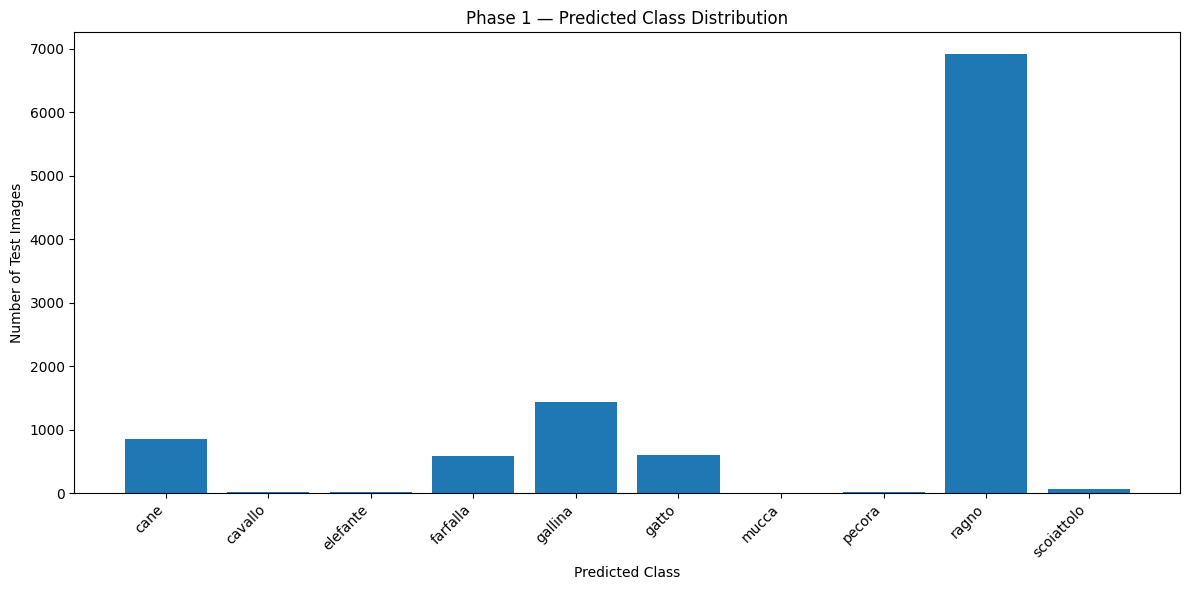

In [24]:
# ============================================================
# CELL 16A — PREDICTION DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt

prediction_counts = (
    submission_df["predicted_label"]
    .value_counts()
    .reindex(CLASS_NAMES, fill_value=0)
)

print("Predicted class distribution:")
display(
    prediction_counts
    .rename("Number of Images")
    .to_frame()
)

# Plot
plt.figure(figsize=(12, 6))

plt.bar(
    prediction_counts.index,
    prediction_counts.values
)

plt.xlabel("Predicted Class")
plt.ylabel("Number of Test Images")
plt.title("Phase 1 — Predicted Class Distribution")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# CELL 16B — CONFIDENCE STATISTICS
# ============================================================

confidence_series = pd.Series(
    all_confidences,
    name="Confidence"
)

confidence_stats = pd.DataFrame({
    "Metric": [
        "Mean Confidence",
        "Median Confidence",
        "Minimum Confidence",
        "Maximum Confidence",
        "Std Confidence"
    ],

    "Value": [
        confidence_series.mean(),
        confidence_series.median(),
        confidence_series.min(),
        confidence_series.max(),
        confidence_series.std()
    ]
})

confidence_stats["Value"] = (
    confidence_stats["Value"] * 100
).round(2)

confidence_stats["Value"] = (
    confidence_stats["Value"].astype(str) + "%"
)

display(confidence_stats)

,Metric,Value
0,Mean Confidence,66.12%
1,Median Confidence,65.26%
2,Minimum Confidence,18.17%
3,Maximum Confidence,99.99%
4,Std Confidence,21.69%


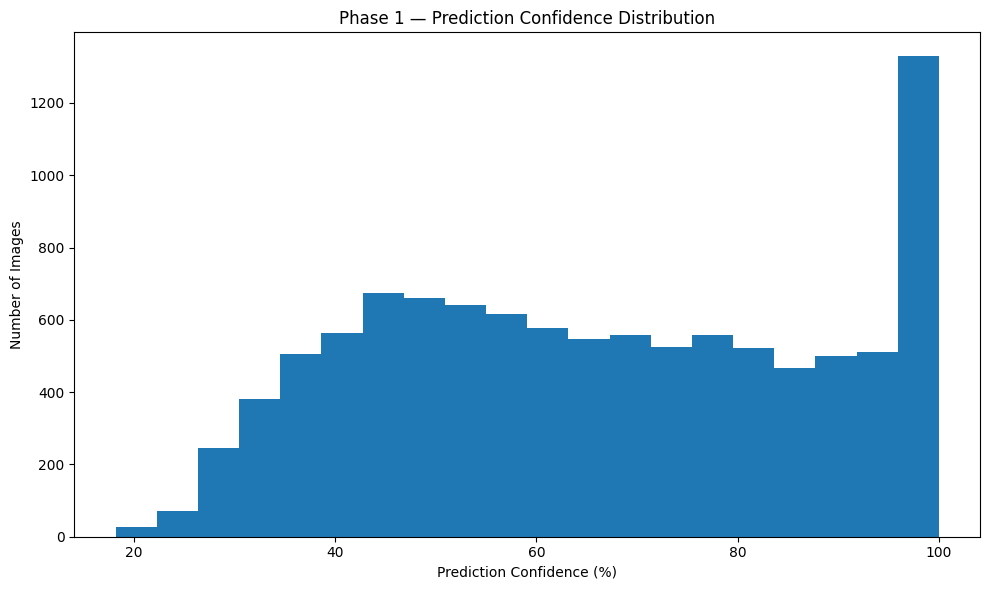

In [26]:
# ============================================================
# CELL 16C — CONFIDENCE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    confidence_series * 100,
    bins=20
)

plt.xlabel("Prediction Confidence (%)")
plt.ylabel("Number of Images")
plt.title("Phase 1 — Prediction Confidence Distribution")

plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# CELL 16D — CONFIDENCE BY CLASS
# ============================================================

confidence_by_class = (
    confidence_df
    .groupby("predicted_label")["confidence"]
    .agg(
        ["count", "mean", "median", "min", "max"]
    )
    .reindex(CLASS_NAMES)
)

confidence_by_class.columns = [
    "Images",
    "Mean Confidence",
    "Median Confidence",
    "Min Confidence",
    "Max Confidence"
]

confidence_by_class[
    [
        "Mean Confidence",
        "Median Confidence",
        "Min Confidence",
        "Max Confidence"
    ]
] *= 100

confidence_by_class = confidence_by_class.round(2)

display(confidence_by_class)

,Images,Mean Confidence,Median Confidence,Min Confidence,Max Confidence
predicted_label,,,,,
cane,848,58.29,54.11,20.57,99.98
cavallo,19,41.78,39.39,20.32,83.69
elefante,10,53.01,43.37,28.10,97.71
farfalla,576,62.05,59.08,19.48,99.96
gallina,1436,58.50,55.09,21.16,99.93
gatto,593,58.40,54.73,20.37,99.93
mucca,7,42.37,42.36,31.28,56.09
pecora,20,39.67,39.01,24.14,61.30
ragno,6910,70.01,70.64,18.17,99.99


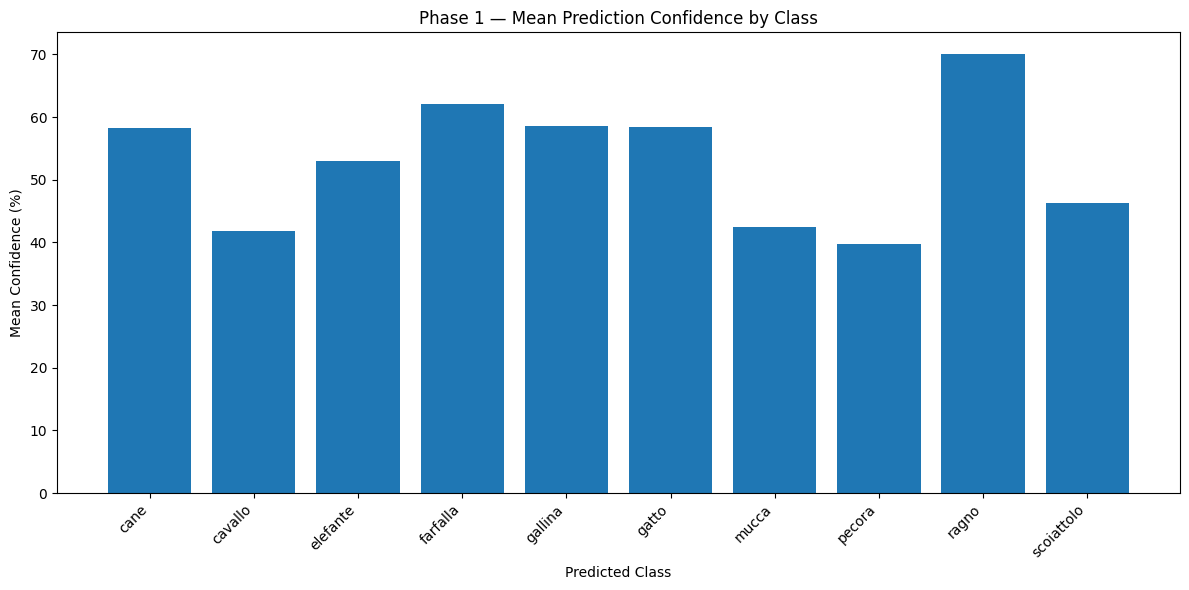

In [28]:
# ============================================================
# CELL 16E — MEAN CONFIDENCE BY CLASS
# ============================================================

mean_confidence = (
    confidence_by_class["Mean Confidence"]
)

plt.figure(figsize=(12, 6))

plt.bar(
    mean_confidence.index,
    mean_confidence.values
)

plt.xlabel("Predicted Class")
plt.ylabel("Mean Confidence (%)")
plt.title("Phase 1 — Mean Prediction Confidence by Class")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

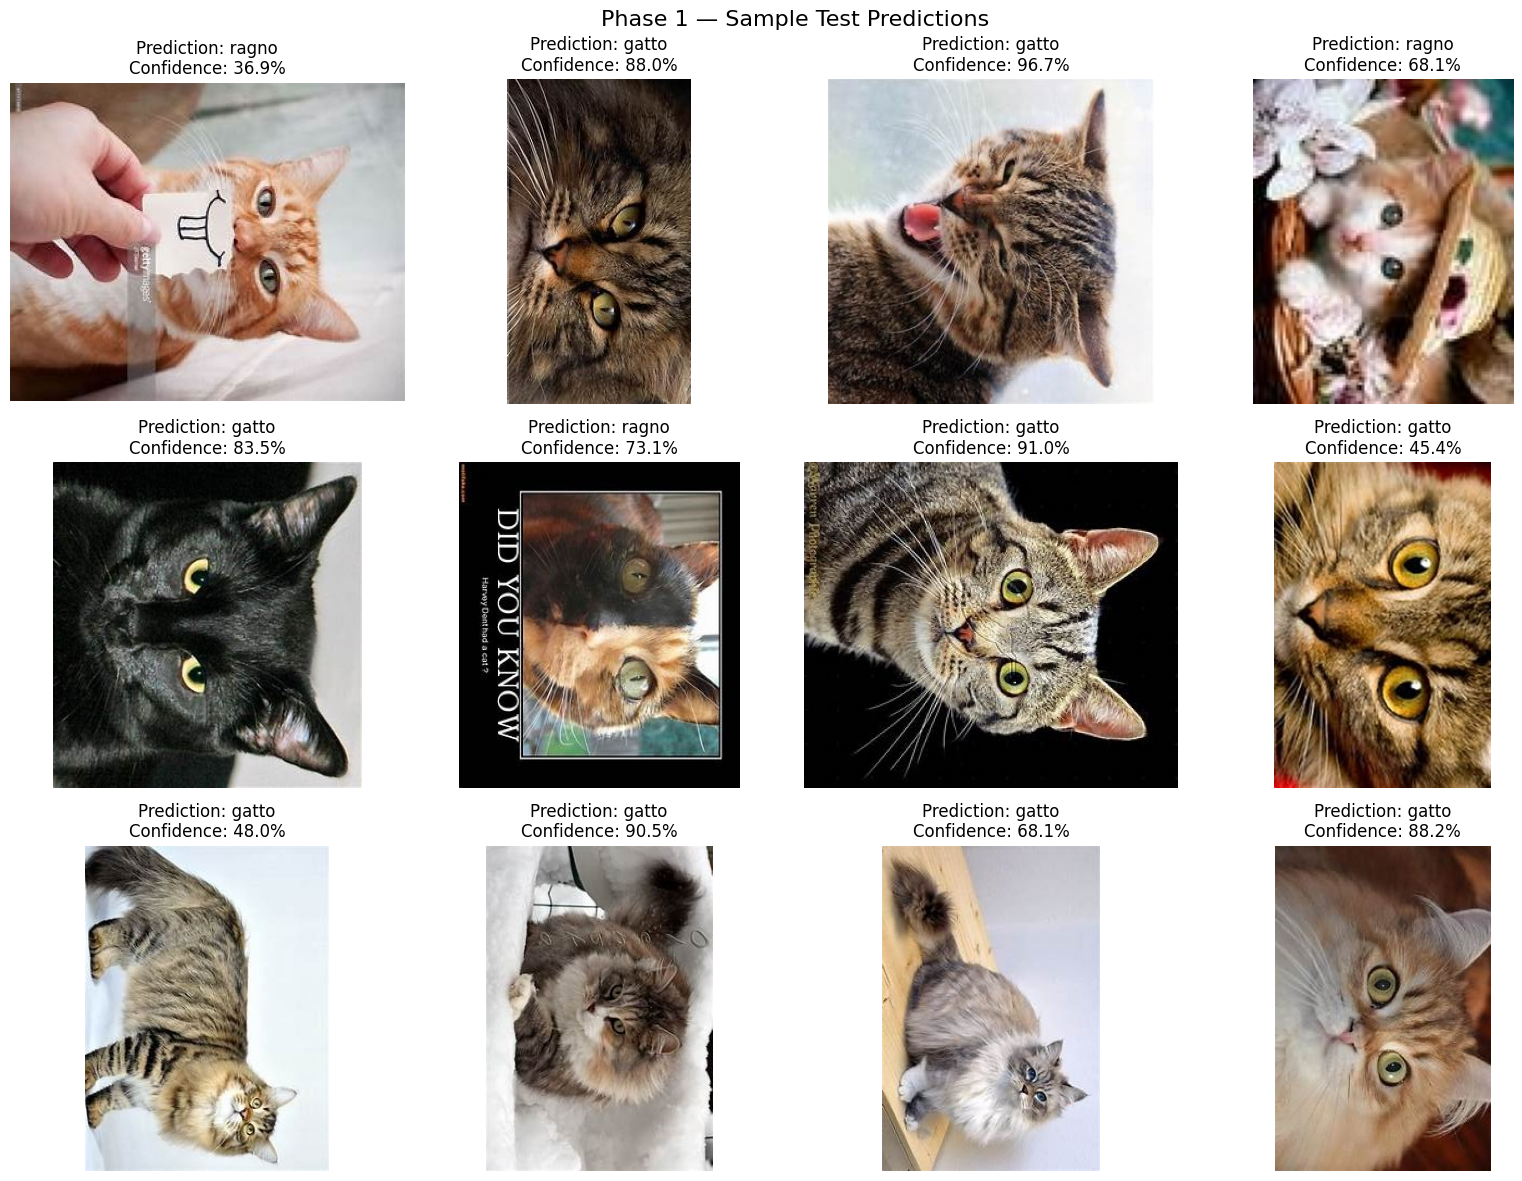

In [29]:
# ============================================================
# CELL 16F — VISUALIZE SAMPLE PREDICTIONS
# ============================================================

import math

NUM_IMAGES = min(12, len(test_image_paths))

cols = 4
rows = math.ceil(NUM_IMAGES / cols)

plt.figure(figsize=(16, 4 * rows))

for i in range(NUM_IMAGES):

    image_path = all_paths[i]

    image = Image.open(
        image_path
    ).convert("RGB")

    prediction = all_predictions[i]

    confidence = all_confidences[i] * 100

    plt.subplot(rows, cols, i + 1)

    plt.imshow(image)

    plt.title(
        f"Prediction: {prediction}\n"
        f"Confidence: {confidence:.1f}%"
    )

    plt.axis("off")

plt.suptitle(
    "Phase 1 — Sample Test Predictions",
    fontsize=16
)

plt.tight_layout()
plt.show()

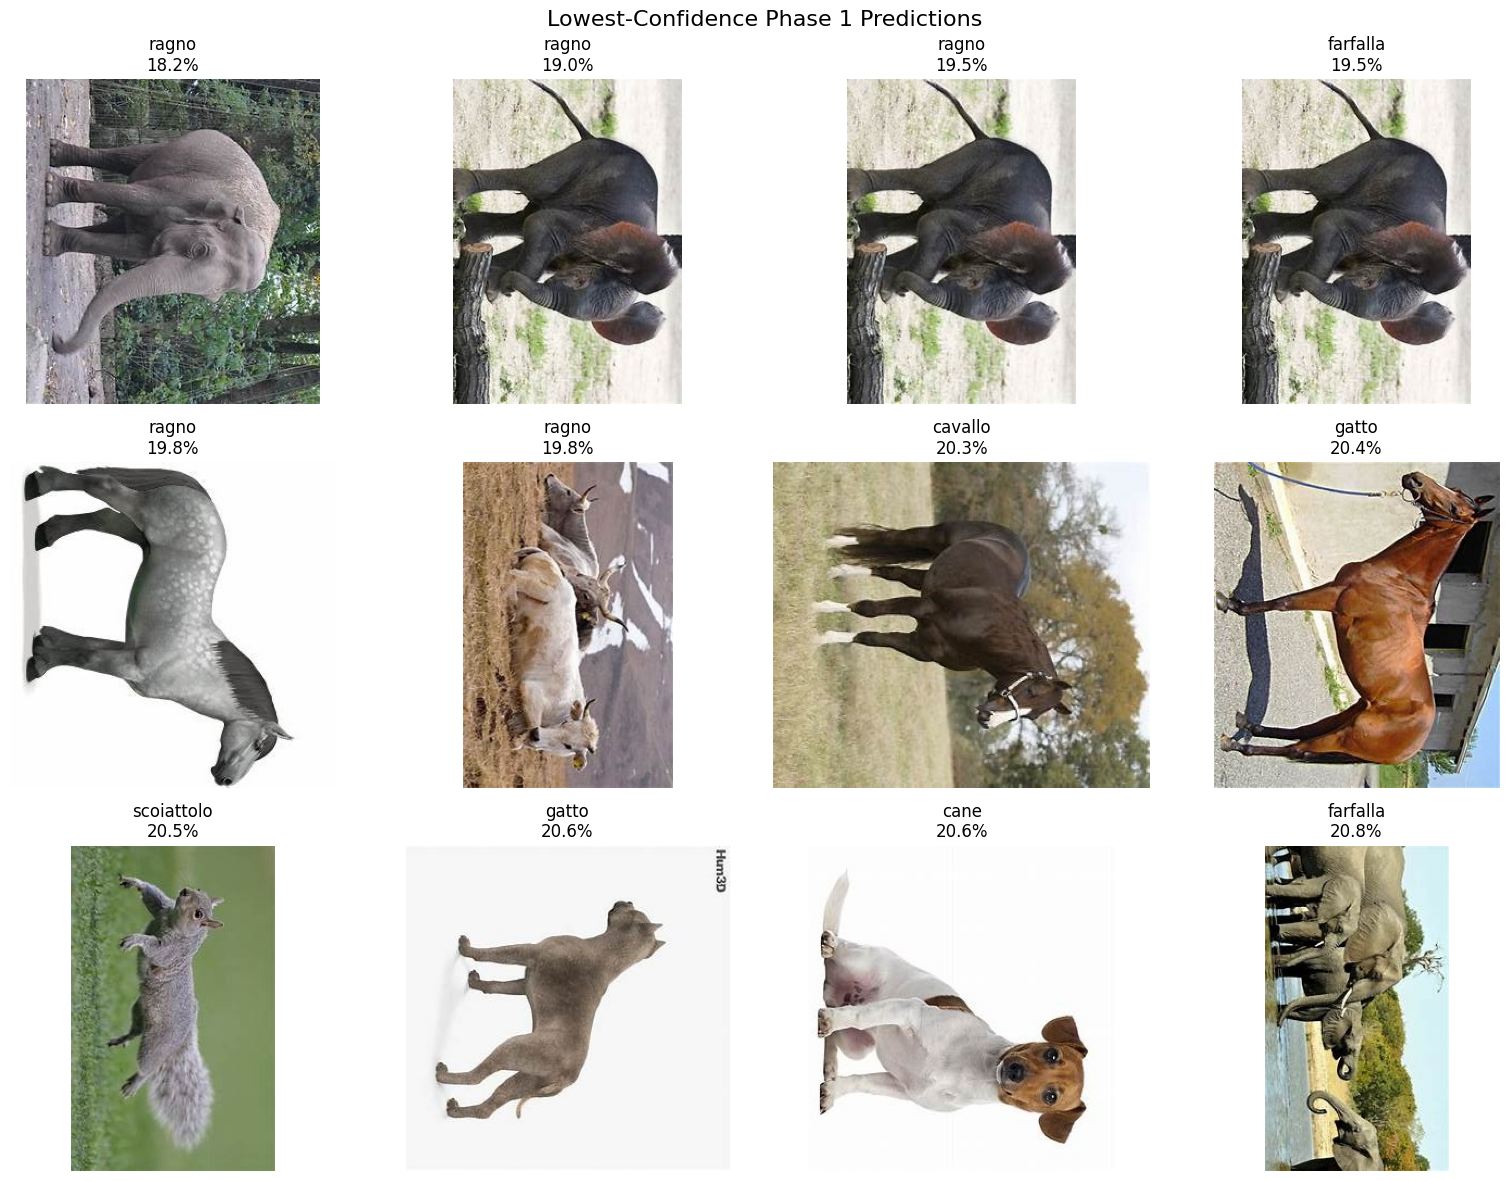

In [30]:
# ============================================================
# CELL 16G — LOWEST CONFIDENCE IMAGES
# ============================================================

num_low_conf = min(
    12,
    len(confidence_df)
)

lowest = (
    confidence_df
    .sort_values(
        "confidence",
        ascending=True
    )
    .head(num_low_conf)
)

cols = 4
rows = math.ceil(num_low_conf / cols)

plt.figure(figsize=(16, 4 * rows))

for i, (_, row) in enumerate(lowest.iterrows()):

    image_path = os.path.join(
        TEST_DIR,
        row["path"]
    )

    image = Image.open(
        image_path
    ).convert("RGB")

    plt.subplot(rows, cols, i + 1)

    plt.imshow(image)

    plt.title(
        f"{row['predicted_label']}\n"
        f"{row['confidence'] * 100:.1f}%"
    )

    plt.axis("off")

plt.suptitle(
    "Lowest-Confidence Phase 1 Predictions",
    fontsize=16
)

plt.tight_layout()
plt.show()

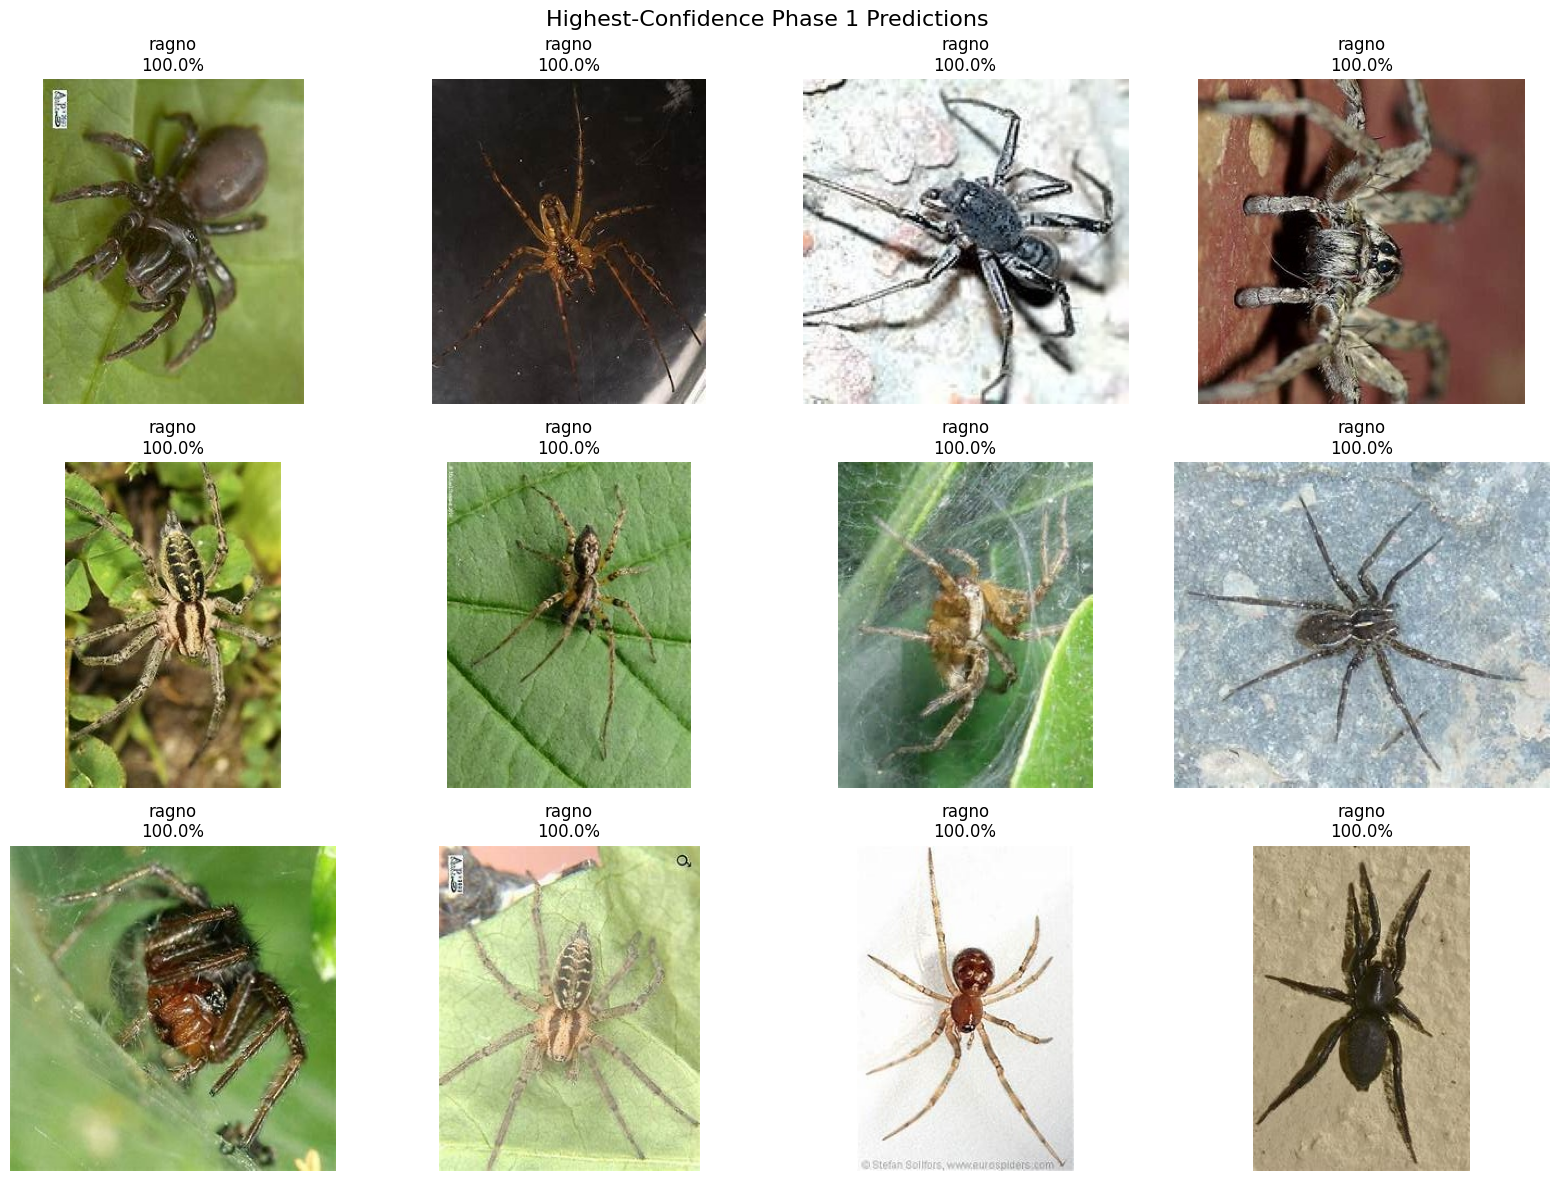

In [31]:
# ============================================================
# CELL 16H — HIGHEST CONFIDENCE IMAGES
# ============================================================

highest = (
    confidence_df
    .sort_values(
        "confidence",
        ascending=False
    )
    .head(12)
)

cols = 4
rows = math.ceil(len(highest) / cols)

plt.figure(figsize=(16, 4 * rows))

for i, (_, row) in enumerate(highest.iterrows()):

    image_path = os.path.join(
        TEST_DIR,
        row["path"]
    )

    image = Image.open(
        image_path
    ).convert("RGB")

    plt.subplot(rows, cols, i + 1)

    plt.imshow(image)

    plt.title(
        f"{row['predicted_label']}\n"
        f"{row['confidence'] * 100:.1f}%"
    )

    plt.axis("off")

plt.suptitle(
    "Highest-Confidence Phase 1 Predictions",
    fontsize=16
)

plt.tight_layout()
plt.show()

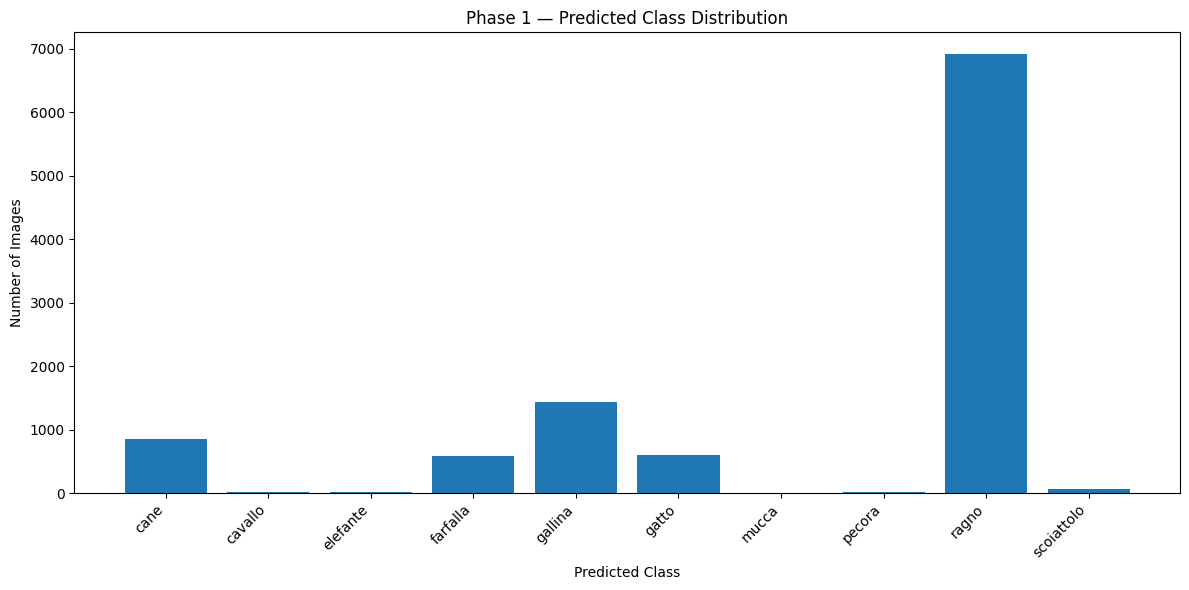

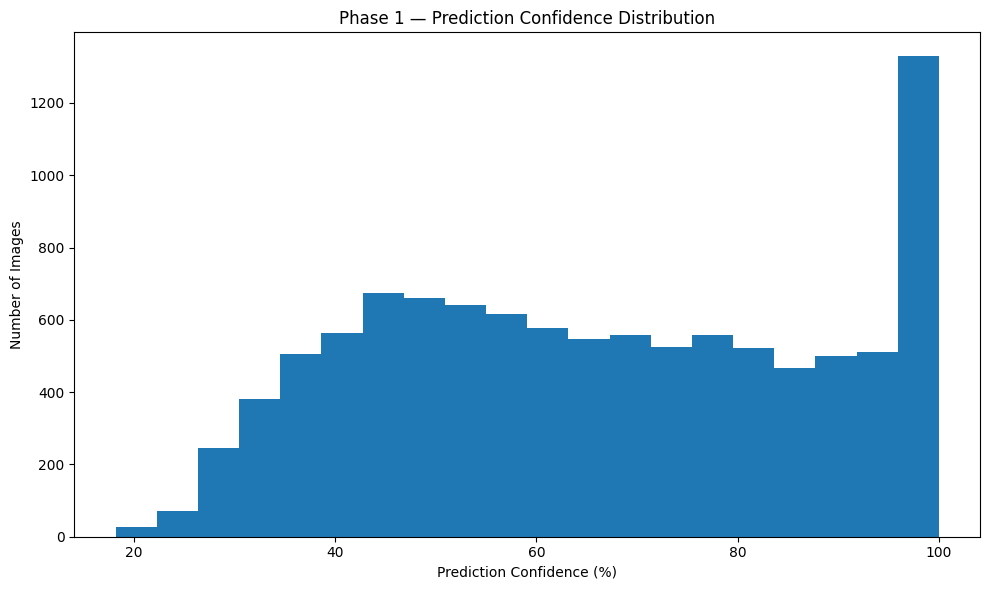

✓ Plots saved to:
C:\Users\srima\Desktop\HyperVerge\hv_ai_outputs\test_Csv\plots


In [32]:
# ============================================================
# CELL 16I — SAVE VISUALIZATIONS
# ============================================================

PLOT_DIR = os.path.join(
    OUTPUT_DIR,
    "plots"
)

os.makedirs(
    PLOT_DIR,
    exist_ok=True
)

# ------------------------------------------------------------
# Class distribution
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.bar(
    prediction_counts.index,
    prediction_counts.values
)

plt.xlabel("Predicted Class")
plt.ylabel("Number of Images")
plt.title("Phase 1 — Predicted Class Distribution")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "phase1_class_distribution.png"
    ),
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# Confidence distribution
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.hist(
    confidence_series * 100,
    bins=20
)

plt.xlabel("Prediction Confidence (%)")
plt.ylabel("Number of Images")
plt.title("Phase 1 — Prediction Confidence Distribution")

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "phase1_confidence_distribution.png"
    ),
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("✓ Plots saved to:")
print(PLOT_DIR)